## 01 Импорт данных ##

In [4]:
import pandas as pd
import numpy as np
import pickle
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Загружаем обработанные данные
print("\n1️⃣ Загрузка обработанного датасета...")
train_df = pd.read_csv('../data/processed/train_processed.csv', sep=';', encoding='utf-8')
print(f"   ✓ Загружено {len(train_df)} записей")

# ЗАГРУЖАЕМ артефакты
print("\n2️⃣ Загрузка артефактов (vectorizer, label_encoder)...")
vectorizer = pickle.load(open('../models/v1.0/vectorizer.pkl', 'rb'))
label_encoder = pickle.load(open('../models/v1.0/label_encoder.pkl', 'rb'))
print("   ✓ Артефакты загружены")

# Проверяем данные
print(f"\n✓ Данные готовы:")
print(f"   processed_text пропусков: {train_df['processed_text'].isna().sum()}")
print(f"   target_encoded пропусков: {train_df['target_encoded'].isna().sum()}")


1️⃣ Загрузка обработанного датасета...
   ✓ Загружено 8565 записей

2️⃣ Загрузка артефактов (vectorizer, label_encoder)...
   ✓ Артефакты загружены

✓ Данные готовы:
   processed_text пропусков: 15
   target_encoded пропусков: 0


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

print("\n" + "="*80)
print("🔄 ПЕРЕОБРАБОТКА ДАННЫХ")
print("="*80)

# Загружаем исходный датасет
train_df = pd.read_csv('../data/service_desk_train.csv', sep=';', encoding='utf-8')

# Создаем processed_text (используя full_text, который вы уже приготовили)
# ГЛАВНОЕ: заполняем пропуски пустой строкой
train_df['full_text'] = train_df['Тема'].fillna('')
train_df['processed_text'] = train_df['full_text'].fillna('')  # ← ВАЖНО!

print(f"✓ processed_text пропусков: {train_df['processed_text'].isna().sum()}")

# Закодируем целевую переменную
label_encoder = LabelEncoder()
train_df['target_encoded'] = label_encoder.fit_transform(train_df['Тип задачи'])

# Создаем TF-IDF
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

print("\nОбучение TF-IDF...")
vectorizer.fit(train_df['processed_text'])


🔄 ПЕРЕОБРАБОТКА ДАННЫХ
✓ processed_text пропусков: 0

Обучение TF-IDF...


,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


## 02 Подготовка данных для обучения ##

In [7]:
print("\n" + "="*80)
print("📊 ПОДГОТОВКА ДАННЫХ")
print("="*80)

# Векторизуем тексты
X = vectorizer.transform(train_df['processed_text'])
y = train_df['target_encoded']

print(f"\nМатрица признаков X:")
print(f"   Форма: {X.shape}")
print(f"   Тип: {type(X)}")

print(f"\nЦелевая переменная y:")
print(f"   Форма: {y.shape}")
print(f"   Уникальные значения: {np.unique(y)}")

# Разделяем на train и validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,  # 20% на валидацию
    random_state=42,
    stratify=y  # Сохраняем пропорции категорий
)

print(f"\n✓ Данные разделены:")
print(f"   Train: {X_train.shape[0]} примеров")
print(f"   Validation: {X_val.shape[0]} примеров")


📊 ПОДГОТОВКА ДАННЫХ

Матрица признаков X:
   Форма: (8565, 5881)
   Тип: <class 'scipy.sparse._csr.csr_matrix'>

Целевая переменная y:
   Форма: (8565,)
   Уникальные значения: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]

✓ Данные разделены:
   Train: 6852 примеров
   Validation: 1713 примеров


## 03 Обучение модели ##

In [8]:
print("\n" + "="*80)
print("🤖 ОБУЧЕНИЕ МОДЕЛИ (Logistic Regression)")
print("="*80)

# Создаем и обучаем модель
print("\nОбучение модели... пожалуйста подождите...")

classifier = LogisticRegression(
    C=1.0,                    # Параметр регуляризации
    max_iter=1000,           # Максимальное количество итераций
    multi_class='multinomial', # Для многоклассовой классификации
    solver='lbfgs',          # Алгоритм оптимизации
    random_state=42,
    n_jobs=-1,               # Использовать все ядра процессора
    verbose=0
)

classifier.fit(X_train, y_train)


🤖 ОБУЧЕНИЕ МОДЕЛИ (Logistic Regression)

Обучение модели... пожалуйста подождите...


C:\Users\aly.nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


## 04 Оценка модели на train и validation ##

In [9]:
print("\n" + "="*80)
print("📈 ОЦЕНКА МОДЕЛИ")
print("="*80)

# Предсказания на training и validation
y_train_pred = classifier.predict(X_train)
y_val_pred = classifier.predict(X_val)

# Метрики на training
train_acc = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_rec = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

# Метрики на validation
val_acc = accuracy_score(y_val, y_val_pred)
val_prec = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_rec = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

print(f"\n📊 МЕТРИКИ НА TRAINING ДАННЫХ:")
print(f"   Accuracy:  {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   Precision: {train_prec:.4f}")
print(f"   Recall:    {train_rec:.4f}")
print(f"   F1-score:  {train_f1:.4f}")

print(f"\n📊 МЕТРИКИ НА VALIDATION ДАННЫХ:")
print(f"   Accuracy:  {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"   Precision: {val_prec:.4f}")
print(f"   Recall:    {val_rec:.4f}")
print(f"   F1-score:  {val_f1:.4f}")

# Проверяем на переобучение
print(f"\n🔍 АНАЛИЗ ПЕРЕОБУЧЕНИЯ:")
diff = train_acc - val_acc
if diff > 0.05:
    print(f"   ⚠️ Возможно переобучение (разница {diff:.4f})")
else:
    print(f"   ✓ Нет значительного переобучения")


📈 ОЦЕНКА МОДЕЛИ

📊 МЕТРИКИ НА TRAINING ДАННЫХ:
   Accuracy:  0.9842 (98.42%)
   Precision: 0.9789
   Recall:    0.9842
   F1-score:  0.9812

📊 МЕТРИКИ НА VALIDATION ДАННЫХ:
   Accuracy:  0.9749 (97.49%)
   Precision: 0.9673
   Recall:    0.9749
   F1-score:  0.9705

🔍 АНАЛИЗ ПЕРЕОБУЧЕНИЯ:
   ✓ Нет значительного переобучения


## 05 Отчет по категориям ##

In [10]:
print("\n" + "="*80)
print("🔬 ДЕТАЛЬНЫЙ ОТЧЕТ ПО КАТЕГОРИЯМ")
print("="*80)

print("\n" + classification_report(
    y_val, 
    y_val_pred, 
    target_names=label_encoder.classes_,
    zero_division=0
))


🔬 ДЕТАЛЬНЫЙ ОТЧЕТ ПО КАТЕГОРИЯМ

                               precision    recall  f1-score   support

 HR: Перевод через увольнение       0.00      0.00      0.00         3
                    HR: Приём       1.00      1.00      1.00        36
   HR: Техническое увольнение       0.00      0.00      0.00         4
               HR: Увольнение       1.00      0.76      0.87        17
                Заказ визиток       0.00      0.00      0.00         1
     Заказ гостевого пропуска       1.00      0.93      0.97        46
       Запрос на обслуживание       0.96      0.99      0.98       948
 Заявка на билет и проживание       1.00      0.93      0.97        30
   Заявка на выход сотрудника       0.96      0.82      0.89        33
    Заявка на согласование ВМ       1.00      0.67      0.80         6
Изменение персональных данных       0.00      0.00      0.00         2
     Изменение условий работы       1.00      1.00      1.00         8
                    Подзадача       0.99  

## 06 Confusion matrix (матрица ошибок) ##

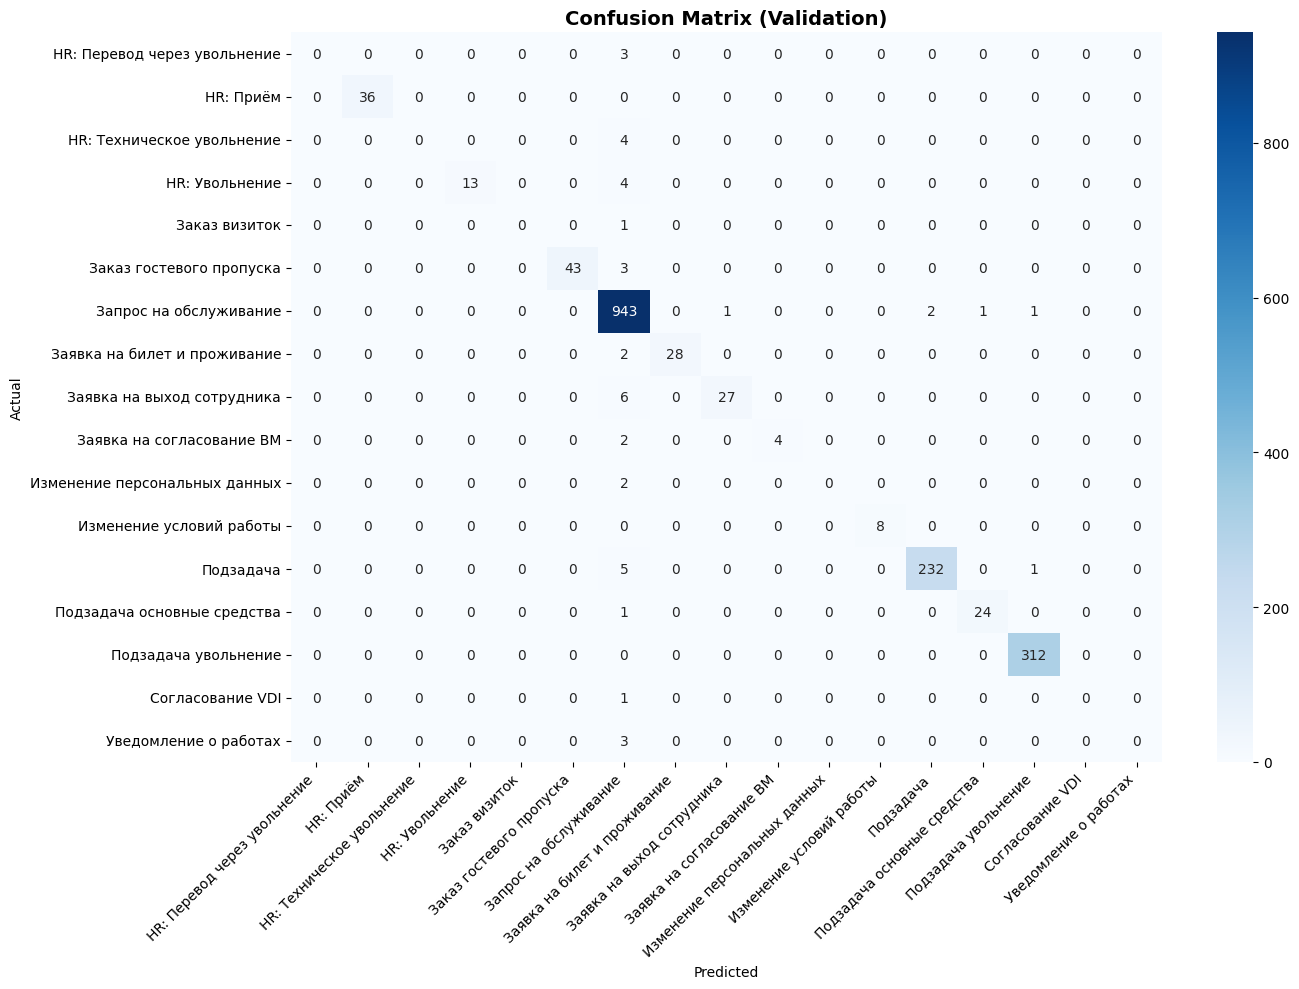

✓ Матрица ошибок сохранена


In [11]:
# Матрица ошибок
cm = confusion_matrix(y_val, y_val_pred)

# Визуализация
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix (Validation)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Матрица ошибок сохранена")

## 07 Cross-validation ##

In [12]:
print("\n" + "="*80)
print("🔄 CROSS-VALIDATION (5-FOLD)")
print("="*80)

# Проводим 5-fold cross-validation
cv_scores = cross_val_score(
    classifier, 
    X_train, 
    y_train, 
    cv=5,  # 5 fold
    scoring='accuracy'
)

print(f"\nОценки для каждого fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score:.4f}")

print(f"\nСредняя оценка: {cv_scores.mean():.4f}")
print(f"Стандартное отклонение: {cv_scores.std():.4f}")


🔄 CROSS-VALIDATION (5-FOLD)


C:\Users\aly.nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\aly.nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\aly.nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\aly.nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: Fut


Оценки для каждого fold:
   Fold 1: 0.9701
   Fold 2: 0.9723
   Fold 3: 0.9693
   Fold 4: 0.9701
   Fold 5: 0.9664

Средняя оценка: 0.9696
Стандартное отклонение: 0.0019


## Сохранение модели ##

In [13]:
print("\n" + "="*80)
print("💾 СОХРАНЕНИЕ МОДЕЛИ")
print("="*80)

# Сохраняем классификатор
with open('../models/v1.0/classifier.pkl', 'wb') as f:
    pickle.dump(classifier, f)

print("✓ Модель сохранена в models/v1.0/classifier.pkl")

# Сохраняем конфигурацию (метаданные)
import json
from datetime import datetime

config = {
    'model_version': '1.0',
    'model_type': 'LogisticRegression',
    'vectorizer': 'TfidfVectorizer',
    'training_date': datetime.now().isoformat(),
    'metrics': {
        'train_accuracy': float(train_acc),
        'val_accuracy': float(val_acc),
        'val_f1_score': float(val_f1),
        'cv_mean': float(cv_scores.mean()),
        'cv_std': float(cv_scores.std())
    },
    'classes': label_encoder.classes_.tolist(),
    'num_classes': len(label_encoder.classes_),
    'num_features': X.shape[1]
}

with open('../models/v1.0/config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("✓ Конфигурация сохранена в models/v1.0/config.json")

print("\n" + "="*80)
print("✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print("="*80)
print("\n📦 Сохраненные файлы:")
print("   - models/v1.0/classifier.pkl (модель)")
print("   - models/v1.0/vectorizer.pkl (векторизатор)")
print("   - models/v1.0/label_encoder.pkl (кодировщик категорий)")
print("   - models/v1.0/config.json (метаданные)")


💾 СОХРАНЕНИЕ МОДЕЛИ
✓ Модель сохранена в models/v1.0/classifier.pkl
✓ Конфигурация сохранена в models/v1.0/config.json

✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!

📦 Сохраненные файлы:
   - models/v1.0/classifier.pkl (модель)
   - models/v1.0/vectorizer.pkl (векторизатор)
   - models/v1.0/label_encoder.pkl (кодировщик категорий)
   - models/v1.0/config.json (метаданные)


## 09 Тестирование на примерах ##

In [14]:
print("\n" + "="*80)
print("🧪 ТЕСТИРОВАНИЕ НА ПРИМЕРАХ")
print("="*80)

# Берем несколько примеров из validation набора
example_indices = [0, 100, 200, 300]

for idx in example_indices:
    # Исходный текст
    original_text = train_df.iloc[idx]['full_text'][:100]
    
    # Истинная категория
    true_category = label_encoder.inverse_transform([y_val.iloc[idx]])[0]
    
    # Предсказание
    predicted_category = label_encoder.inverse_transform([y_val_pred[idx]])[0]
    
    # Уверенность
    probabilities = classifier.predict_proba(X_val[idx])[0]
    max_prob = np.max(probabilities)
    
    # Результат
    result = "✓" if true_category == predicted_category else "✗"
    
    print(f"\n{result} Пример:")
    print(f"   Текст: {original_text}...")
    print(f"   Истинная категория: {true_category}")
    print(f"   Предсказанная категория: {predicted_category}")
    print(f"   Уверенность: {max_prob:.2%}")


🧪 ТЕСТИРОВАНИЕ НА ПРИМЕРАХ

✓ Пример:
   Текст: Утерян пропуск Рымарь В.С....
   Истинная категория: Подзадача увольнение
   Предсказанная категория: Подзадача увольнение
   Уверенность: 92.07%

✓ Пример:
   Текст: Бухгалтерия. Сформировать акт приема-передачи для Дабаев Дмитрий Баирович , 9/15/25...
   Истинная категория: Подзадача увольнение
   Предсказанная категория: Подзадача увольнение
   Уверенность: 93.13%

✓ Пример:
   Текст: Оборудование - Ильбахтин Семён Сергеевич, БФТ...
   Истинная категория: Подзадача
   Предсказанная категория: Подзадача
   Уверенность: 71.92%

✓ Пример:
   Текст: Оборудование - Куриков Дмитрий Вениаминович, БФТ...
   Истинная категория: Запрос на обслуживание
   Предсказанная категория: Запрос на обслуживание
   Уверенность: 93.51%


## 10 Дообучение ##  
Мы увидели большое количество ошибок при определении типа задач с HR и увольнением. Это связано с малым кол-вом примеров по данным задачам (от 4 до 15 примеров). Требуется отбалансировать модель. Применим SMOTE (синтетические данные) и балансировку

In [23]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

print("\n" + "="*80)
print("🤖 ОБУЧЕНИЕ МОДЕЛИ СО СМОТОМ И БАЛАНСИРОВКОЙ")
print("="*80)

# === SMOTE с низким k_neighbors ===
print("\n1️⃣ Балансировка данных через SMOTE...")

smote = SMOTE(k_neighbors=2, random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"   До SMOTE: {len(y_train)} примеров")
print(f"   После SMOTE: {len(y_train_balanced)} примеров")

# Анализируем распределение
from collections import Counter
before_counts = Counter(y_train)
after_counts = Counter(y_train_balanced)

print(f"\n   Распределение классов ПОСЛЕ SMOTE:")
for class_id in sorted(after_counts.keys()):
    class_name = label_encoder.inverse_transform([class_id])[0]
    count = after_counts[class_id]
    print(f"      {class_name}: {count}")

# === ОБУЧЕНИЕ ===
print("\n2️⃣ Обучение модели...")

classifier = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',  # ← Используем И это тоже!
    verbose=0
)

classifier.fit(X_train_balanced, y_train_balanced)

print("   ✓ Модель обучена!")

# === ОЦЕНКА ===
print("\n3️⃣ Оценка на validation...")

y_val_pred = classifier.predict(X_val)

val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

print(f"   Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"   Validation F1-score: {val_f1:.4f}")

# === СОХРАНЕНИЕ ===
print("\n4️⃣ Сохранение улучшенной модели...")

import joblib
joblib.dump(classifier, '../models/v1.0/classifier_smote.pkl')

print("   ✓ Модель сохранена как classifier_smote.pkl")


🤖 ОБУЧЕНИЕ МОДЕЛИ СО СМОТОМ И БАЛАНСИРОВКОЙ

1️⃣ Балансировка данных через SMOTE...
   До SMOTE: 6852 примеров
   После SMOTE: 64447 примеров

   Распределение классов ПОСЛЕ SMOTE:
      HR: Перевод через увольнение: 3791
      HR: Приём: 3791
      HR: Техническое увольнение: 3791
      HR: Увольнение: 3791
      Заказ визиток: 3791
      Заказ гостевого пропуска: 3791
      Запрос на обслуживание: 3791
      Заявка на билет и проживание: 3791
      Заявка на выход сотрудника: 3791
      Заявка на согласование ВМ: 3791
      Изменение персональных данных: 3791
      Изменение условий работы: 3791
      Подзадача: 3791
      Подзадача основные средства: 3791
      Подзадача увольнение: 3791
      Согласование VDI: 3791
      Уведомление о работах: 3791

2️⃣ Обучение модели...
   ✓ Модель обучена!

3️⃣ Оценка на validation...
   Validation Accuracy: 0.9854 (98.54%)
   Validation F1-score: 0.9860

4️⃣ Сохранение улучшенной модели...
   ✓ Модель сохранена как classifier_smote.pkl
